# Corrected Mean-Reversion Alpha Notebook

This notebook runs the corrected residual-return mean-reversion pipeline on a deterministic synthetic panel. The goal is to make the numbers visible and auditable before plugging in real point-in-time data.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from mean_reversion_alpha_lib import run_synthetic_smoke_test

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")

Matplotlib is building the font cache; this may take a moment.


## Run the smoke test

In [2]:
result = run_synthetic_smoke_test(seed=7)
backtest = result["backtest"]
metrics = pd.Series(backtest["metrics"])
metrics

observations             650.0000
total_return               0.1392
cagr                       0.0518
annualized_volatility      0.0232
sharpe                     2.1931
sortino                    3.0360
max_drawdown              -0.0199
calmar                     2.6088
hit_rate                   0.3277
average_daily_turnover     0.3101
dtype: float64

## Performance

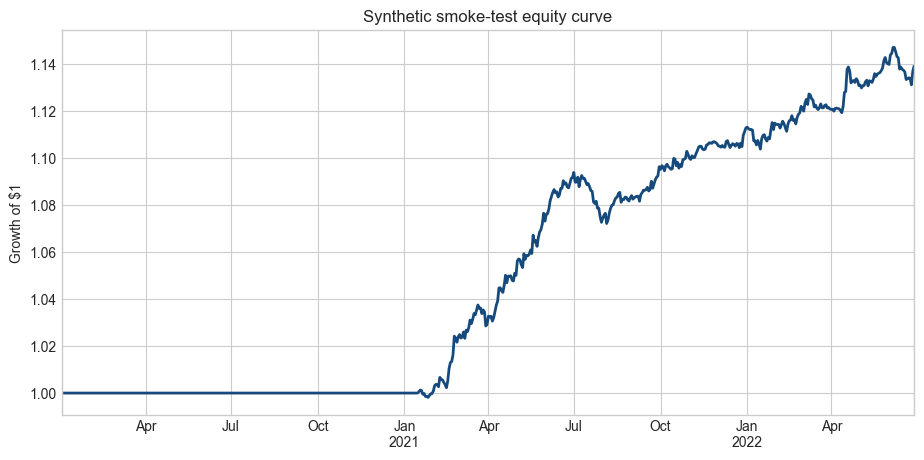

In [3]:
fig, ax = plt.subplots(figsize=(11, 5))
backtest["equity_curve"].plot(ax=ax, color="#174A7C", linewidth=2)
ax.set_title("Synthetic smoke-test equity curve")
ax.set_ylabel("Growth of $1")
ax.set_xlabel("")
plt.show()

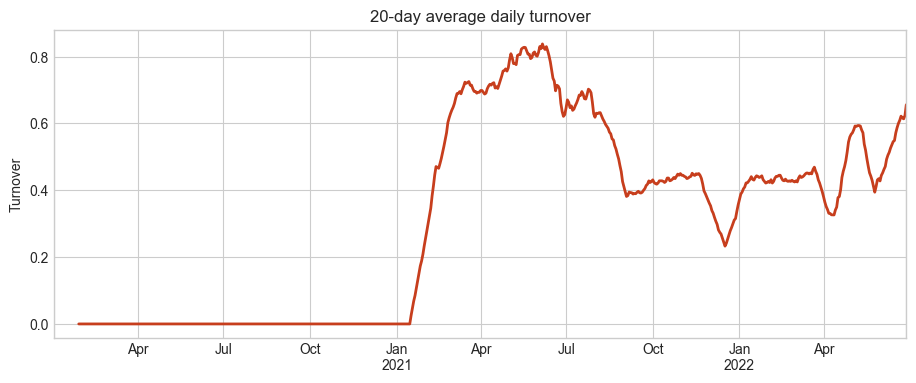

In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
backtest["turnover"].rolling(20).mean().plot(ax=ax, color="#C73E1D", linewidth=2)
ax.set_title("20-day average daily turnover")
ax.set_ylabel("Turnover")
ax.set_xlabel("")
plt.show()

## Regime checks

In [5]:
vol_regime = result["volatility_regime"]
trend_regime = result["trend_regime"]

display(vol_regime["label"].value_counts(dropna=False).rename("volatility_regime_days"))
display(trend_regime.value_counts(dropna=False).rename("trend_regime_days"))

label
normal     275
high       167
low        156
unknown     52
Name: volatility_regime_days, dtype: int64

bear        326
sideways    161
unknown     125
bull         38
Name: trend_regime_days, dtype: int64

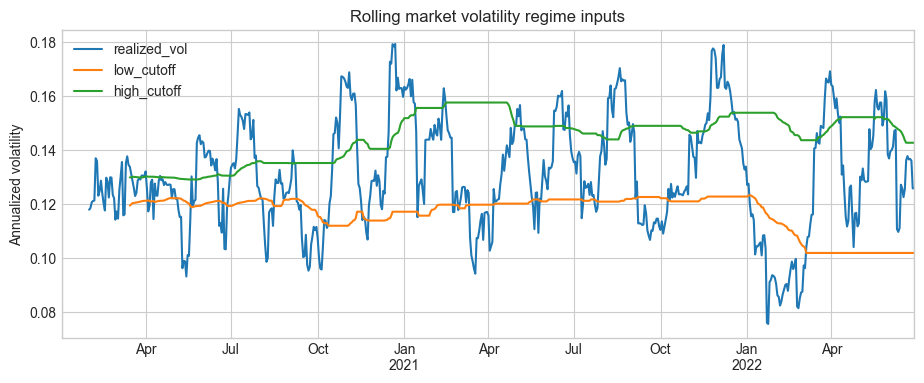

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
vol_regime[["realized_vol", "low_cutoff", "high_cutoff"]].plot(ax=ax, linewidth=1.5)
ax.set_title("Rolling market volatility regime inputs")
ax.set_ylabel("Annualized volatility")
ax.set_xlabel("")
plt.show()

## Universe and exposure checks

In [7]:
universe_count = result["universe"].sum(axis=1)
gross_exposure = result["target_weights"].abs().sum(axis=1)
net_exposure = result["target_weights"].sum(axis=1)

pd.DataFrame({
    "universe_count": universe_count.describe(),
    "gross_exposure": gross_exposure.describe(),
    "net_exposure": net_exposure.describe(),
})

,universe_count,gross_exposure,net_exposure
count,650.0000,650.0000,650.0000
mean,80.6154,0.3474,-0.0000
std,39.5614,0.3346,0.0000
min,0.0000,0.0000,-0.0000
25%,100.0000,0.0000,0.0000
50%,100.0000,0.4400,0.0000
75%,100.0000,0.5000,0.0000
max,100.0000,1.0000,0.0000


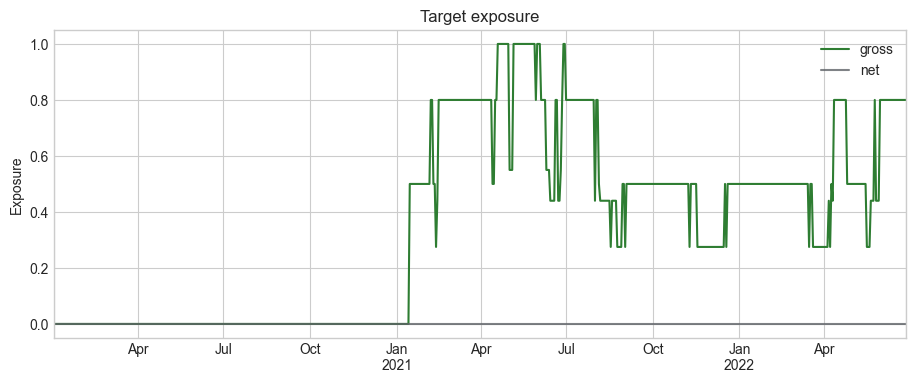

In [8]:
fig, ax = plt.subplots(figsize=(11, 4))
gross_exposure.plot(ax=ax, color="#2E7D32", label="gross")
net_exposure.plot(ax=ax, color="#5F6368", label="net", alpha=0.8)
ax.set_title("Target exposure")
ax.set_ylabel("Exposure")
ax.set_xlabel("")
ax.legend()
plt.show()

## Optional: execute regression tests from the notebook

In [9]:
# Uncomment if you want to run the tests from inside Jupyter.
# %run -m pytest -q